# Análise Exploratória de Dados - `happyT_A`

Este notebook realiza a etapa inicial de **Análise Exploratória de Dados (EDA)** para o conjunto `happyT_A.txt`, usado em um problema de **estimação de redshift fotométrico**. A análise busca compreender a estrutura da base, verificar sua qualidade, caracterizar distribuições e levantar evidências que orientem decisões posteriores de pré-processamento e engenharia de atributos.

As variáveis centrais do problema são:

- magnitudes fotométricas nas bandas `u`, `g`, `r`, `i`, `z`;
- erros fotométricos correspondentes `uErr`, `gErr`, `rErr`, `iErr`, `zErr`;
- alvo `redshift`;
- erro associado ao alvo `redshiftErr`, que será analisado, mas **não deve ser assumido automaticamente como atributo preditivo**, pois em um cenário real de inferência ele pode não estar disponível para novos objetos.


## 1. Carregamento dos dados

Nesta etapa, carregamos o arquivo bruto, definimos explicitamente os nomes esperados das colunas e exibimos um panorama inicial da base. Como o arquivo pode conter cabeçalhos comentados com `#`, a leitura considera esse detalhe.


In [1]:
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


In [2]:
data_path = Path("../data/raw/happyT_A.txt")

expected_columns = [
    "id", "u", "g", "r", "i", "z",
    "uErr", "gErr", "rErr", "iErr", "zErr",
    "redshift", "redshiftErr",
]

mag_cols = ["u", "g", "r", "i", "z"]
err_cols = ["uErr", "gErr", "rErr", "iErr", "zErr"]
target_col = "redshift"
target_err_col = "redshiftErr"

df = pd.read_csv(
    data_path,
    sep=r"\s+",
    comment="#",
    names=expected_columns,
)

print(f"Shape da base: {df.shape[0]:,} linhas x {df.shape[1]:,} colunas")
print("\nNomes das colunas lidas:")
print(df.columns.tolist())


Shape da base: 74,950 linhas x 13 colunas

Nomes das colunas lidas:
['id', 'u', 'g', 'r', 'i', 'z', 'uErr', 'gErr', 'rErr', 'iErr', 'zErr', 'redshift', 'redshiftErr']


In [3]:
display(df.head())

info_buffer = StringIO()
df.info(buf=info_buffer)
print(info_buffer.getvalue())

display(df.drop(columns=["id"]).describe(include="all"))

,id,u,g,r,i,z,uErr,gErr,rErr,iErr,zErr,redshift,redshiftErr
0,1237645879562928805,25.155375,22.232981,21.257841,19.889854,19.427107,1.034657,0.219033,0.206952,0.147347,0.228686,0.752707,0.000287
1,1237645942905504040,21.910667,19.464439,18.372978,17.955502,17.642979,0.443852,0.060666,0.064809,0.069981,0.096798,0.164360,0.000066
2,1237645942905635180,20.978670,20.276821,19.472305,19.232706,18.994177,0.150120,0.070810,0.076891,0.085570,0.132459,0.326150,0.000011
3,1237645942906224860,20.389980,19.313643,17.891615,17.415066,17.181231,0.331636,0.113295,0.092397,0.093178,0.127449,0.274926,0.000063
4,1237645943978721520,23.907169,23.448675,20.256517,19.163860,18.557152,1.527960,1.033415,0.177488,0.132869,0.149485,0.592983,0.000148


<class 'pandas.DataFrame'>
RangeIndex: 74950 entries, 0 to 74949
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           74950 non-null  int64  
 1   u            74950 non-null  float64
 2   g            74950 non-null  float64
 3   r            74950 non-null  float64
 4   i            74950 non-null  float64
 5   z            74950 non-null  float64
 6   uErr         74950 non-null  float64
 7   gErr         74950 non-null  float64
 8   rErr         74950 non-null  float64
 9   iErr         74950 non-null  float64
 10  zErr         74950 non-null  float64
 11  redshift     74950 non-null  float64
 12  redshiftErr  74950 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 7.4 MB



,u,g,r,i,z,uErr,gErr,rErr,iErr,zErr,redshift,redshiftErr
count,"74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000","74,950.000000"
mean,22.088931,20.236337,18.911176,18.224478,17.865348,0.489029,0.129200,0.093469,0.094140,0.140991,0.350706,0.000212
std,2.358682,2.023045,1.679568,1.450241,1.406706,0.457213,0.196016,0.100895,0.098290,0.121952,0.210272,0.014277
min,11.670498,10.543657,10.713271,10.601875,10.677568,0.011919,0.022127,0.034476,0.040540,0.047619,0.000006,0.000003
25%,20.025256,18.322425,17.451256,17.039167,16.749389,0.080535,0.038936,0.054644,0.068161,0.098749,0.135274,0.000025
50%,22.349543,20.870521,19.229371,18.552001,18.160522,0.383301,0.093428,0.078035,0.084909,0.123817,0.374342,0.000076
75%,23.845766,21.933994,20.386323,19.457471,19.018513,0.765475,0.174709,0.117524,0.107340,0.158156,0.529428,0.000140
max,31.474758,28.651567,27.929350,28.221367,29.105049,11.780122,32.901323,8.897392,13.247561,9.394168,1.471981,2.779110


As estatísticas descritivas indicam diferenças significativas de escala entre os grupos de atributos. As magnitudes fotométricas (u, g, r, i e z) apresentam médias entre aproximadamente 18 e 22, enquanto os erros fotométricos possuem médias inferiores a 0,5. O redshift, por sua vez, apresenta média de 0,35, situando-se em uma escala mais próxima dos erros do que das magnitudes. Essas diferenças podem influenciar modelos sensíveis à escala dos dados, como regressões, redes neurais e métodos baseados em distância, tornando a padronização das variáveis uma etapa relevante a ser investigada durante o pré-processamento. Além disso, observa-se que o erro da banda u possui magnitude consideravelmente superior aos demais erros fotométricos, sugerindo uma maior variabilidade nas medições dessa banda.

## 2. Verificação inicial da qualidade da base

Antes de discutir distribuições ou propor transformações, é importante verificar se a base apresenta problemas estruturais que possam comprometer etapas posteriores. Aqui investigamos:

- valores nulos;
- tipos de dados;
- duplicatas gerais e duplicatas no identificador `id`;
- valores infinitos;
- valores negativos em magnitudes, erros e redshift;
- linhas com erros iguais a zero;
- quantidade de zeros em cada feature;
- observações com valores muito extremos em magnitudes e erros.

A ideia é separar o que é apenas comportamento natural do domínio astronômico daquilo que sugere ruído, baixa qualidade de medição ou necessidade de filtragem futura.


In [25]:
# Funções usadas para criar tabelas de contagem e porcentagem, e para exibir seções com títulos formatados.
def build_count_percent_table(series: pd.Series, total_rows: int, count_name: str = "count") -> pd.DataFrame: 
    summary = pd.DataFrame({count_name: series})
    summary["percent"] = 100 * summary[count_name] / total_rows
    return summary


def display_section(title: str) -> None: 
    display(Markdown(f"### {title}"))


In [26]:
# Funções usadas para criar tabelas de contagem e porcentagem, e para exibir seções com títulos formatados.
n_rows = len(df)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = mag_cols + err_cols + [target_col, target_err_col]

null_summary = build_count_percent_table(df.isna().sum(), n_rows, count_name="null_count")
dtype_summary = pd.DataFrame({"dtype": df.dtypes.astype(str)})
inf_summary = build_count_percent_table(np.isinf(df[numeric_cols]).sum(), n_rows, count_name="inf_count")

duplicate_summary = pd.DataFrame(
    {
        "count": [df.duplicated().sum(), df.duplicated(subset=["id"]).sum()],
    },
    index=["duplicated_rows", "duplicated_id"],
)
duplicate_summary["percent"] = 100 * duplicate_summary["count"] / n_rows

negative_checks = {
    "negative_magnitude_rows": (df[mag_cols] < 0).any(axis=1).sum(),
    "negative_error_rows": (df[err_cols] < 0).any(axis=1).sum(),
    "negative_redshift_rows": (df[target_col] < 0).sum(),
    "negative_redshiftErr_rows": (df[target_err_col] < 0).sum(),
}
negative_summary = build_count_percent_table(pd.Series(negative_checks), n_rows)

zero_error_checks = {
    "rows_with_any_zero_photometric_error": (df[err_cols] == 0).any(axis=1).sum(),
    "rows_with_zero_redshiftErr": (df[target_err_col] == 0).sum(),
}
zero_error_summary = build_count_percent_table(pd.Series(zero_error_checks), n_rows)
zero_feature_summary = build_count_percent_table((df[feature_cols] == 0).sum(), n_rows, count_name="zero_count")

display_section("Valores nulos por coluna")
display(null_summary)

display_section("Tipos de dados")
display(dtype_summary)

display_section("Valores infinitos por coluna numérica")
display(inf_summary)

display_section("Duplicatas")
display(duplicate_summary)

display_section("Valores negativos")
display(negative_summary)

display_section("Linhas com erros iguais a zero")
display(zero_error_summary)

display_section("Quantidade de zeros por feature")
display(zero_feature_summary.sort_values("zero_count", ascending=False))


### Valores nulos por coluna

,null_count,percent
id,0,0.000000
u,0,0.000000
g,0,0.000000
r,0,0.000000
i,0,0.000000
z,0,0.000000
uErr,0,0.000000
gErr,0,0.000000
rErr,0,0.000000
iErr,0,0.000000


### Tipos de dados

,dtype
id,int64
u,float64
g,float64
r,float64
i,float64
z,float64
uErr,float64
gErr,float64
rErr,float64
iErr,float64


### Valores infinitos por coluna numérica

...

,count,percent
negative_magnitude_rows,0,0.000000
negative_error_rows,0,0.000000
negative_redshift_rows,0,0.000000
negative_redshiftErr_rows,0,0.000000


### Linhas com erros iguais a zero

,count,percent
rows_with_any_zero_photometric_error,0,0.000000
rows_with_zero_redshiftErr,0,0.000000


### Quantidade de zeros por feature

,zero_count,percent
u,0,0.000000
g,0,0.000000
r,0,0.000000
i,0,0.000000
z,0,0.000000
uErr,0,0.000000
gErr,0,0.000000
rErr,0,0.000000
iErr,0,0.000000
zErr,0,0.000000


Valor extremo é uma observação que se encontra muito distante da faixa central da distribuição de uma variável. Nesta análise, um valor foi considerado extremo quando ficou abaixo de Q1 - 1.5 * IQR ou acima de Q3 + 1.5 * IQR, onde Q1 e Q3 são os quartis de 25% e 75%, e IQR = Q3 - Q1. Isso não implica necessariamente erro de medição, mas sinaliza observações atípicas que merecem investigação, especialmente por poderem representar baixa qualidade fotométrica, caudas longas na distribuição ou casos raros relevantes para a modelagem.

In [27]:
extreme_cols = mag_cols + err_cols
q1 = df[extreme_cols].quantile(0.25)
q3 = df[extreme_cols].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

extreme_summary = pd.DataFrame(index=extreme_cols)
extreme_summary["lower_fence"] = lower_fence
extreme_summary["upper_fence"] = upper_fence
extreme_summary["below_lower_fence"] = [int((df[col] < lower_fence[col]).sum()) for col in extreme_cols]
extreme_summary["above_upper_fence"] = [int((df[col] > upper_fence[col]).sum()) for col in extreme_cols]
extreme_summary["total_extreme"] = extreme_summary["below_lower_fence"] + extreme_summary["above_upper_fence"]
extreme_summary["percent_extreme"] = 100 * extreme_summary["total_extreme"] / n_rows

rows_with_extreme_mag = ((df[mag_cols] < lower_fence[mag_cols]) | (df[mag_cols] > upper_fence[mag_cols])).any(axis=1).sum()
rows_with_extreme_err = ((df[err_cols] < lower_fence[err_cols]) | (df[err_cols] > upper_fence[err_cols])).any(axis=1).sum()

row_extreme_summary = build_count_percent_table(
    pd.Series(
        {
            "rows_with_extreme_magnitudes": rows_with_extreme_mag,
            "rows_with_extreme_errors": rows_with_extreme_err,
        }
    ),
    n_rows,
)

display_section("Resumo de valores muito extremos via regra do IQR")
display(extreme_summary.sort_values("percent_extreme", ascending=False))

display_section("Linhas com ao menos um valor extremo")
display(row_extreme_summary)


### Resumo de valores muito extremos via regra do IQR

,lower_fence,upper_fence,below_lower_fence,above_upper_fence,total_extreme,percent_extreme
zErr,0.009640,0.247265,0,3253,3253,4.340227
gErr,-0.164723,0.378368,0,2591,2591,3.456971
iErr,0.009394,0.166107,0,2475,2475,3.302201
rErr,-0.039675,0.211843,0,1627,1627,2.170781
uErr,-0.946873,1.792884,0,929,929,1.239493
z,13.345702,22.422200,183,97,280,0.373582
i,13.411712,23.084927,133,29,162,0.216144
r,13.048654,24.788925,41,7,48,0.064043
g,12.905070,27.351349,10,1,11,0.014676
u,14.294491,29.576532,9,2,11,0.014676


### Linhas com ao menos um valor extremo

,count,percent
rows_with_extreme_magnitudes,304,0.405604
rows_with_extreme_errors,6700,8.939293


### Leituras iniciais da qualidade da base

A inspeção inicial indica que a base apresenta boa qualidade estrutural para utilização em modelos de aprendizado de máquina. Não foram identificados valores nulos, infinitos ou registros duplicados, tanto considerando as linhas completas quanto o identificador dos objetos. Além disso, todas as variáveis foram carregadas em formatos numéricos adequados (`float64` para atributos contínuos e `int64` para o identificador), não sendo necessárias conversões de tipo nesta etapa.

Também não foram encontrados valores fisicamente inconsistentes, como magnitudes negativas, erros fotométricos negativos, redshifts negativos ou incertezas de redshift iguais a zero. A contagem de zeros por feature complementa esse diagnóstico ao mostrar em quais variáveis esse valor aparece e com que frequência, distinguindo casos estruturalmente aceitáveis de possíveis sinais de baixa variabilidade ou necessidade de atenção futura.

A análise de valores extremos utilizando a regra do IQR mostrou comportamentos distintos entre magnitudes e erros fotométricos. As magnitudes apresentam uma quantidade muito pequena de observações classificadas como extremas, representando menos de 0,5% da base. Em contrapartida, os erros fotométricos concentram uma parcela significativamente maior de valores acima do limite superior do IQR, especialmente nas bandas z, g e i.

No total, apenas 304 objetos (0,41%) possuem pelo menos uma magnitude extrema, enquanto 6.700 objetos (8,94%) apresentam ao menos um erro fotométrico extremo. Como erros elevados estão frequentemente associados a observações de menor qualidade ou menor relação sinal-ruído, esses registros não devem ser tratados automaticamente como erros de coleta. Pelo contrário, podem representar uma fonte relevante de informação para a investigação proposta, que busca avaliar o impacto das incertezas fotométricas na estimativa de redshift.


## 3. Estatísticas descritivas gerais

Nesta etapa, vamos inspecionar visualmente o comportamento das magnitudes, dos erros fotométricos e das variáveis associadas ao redshift por meio de histogramas separados por grupo.


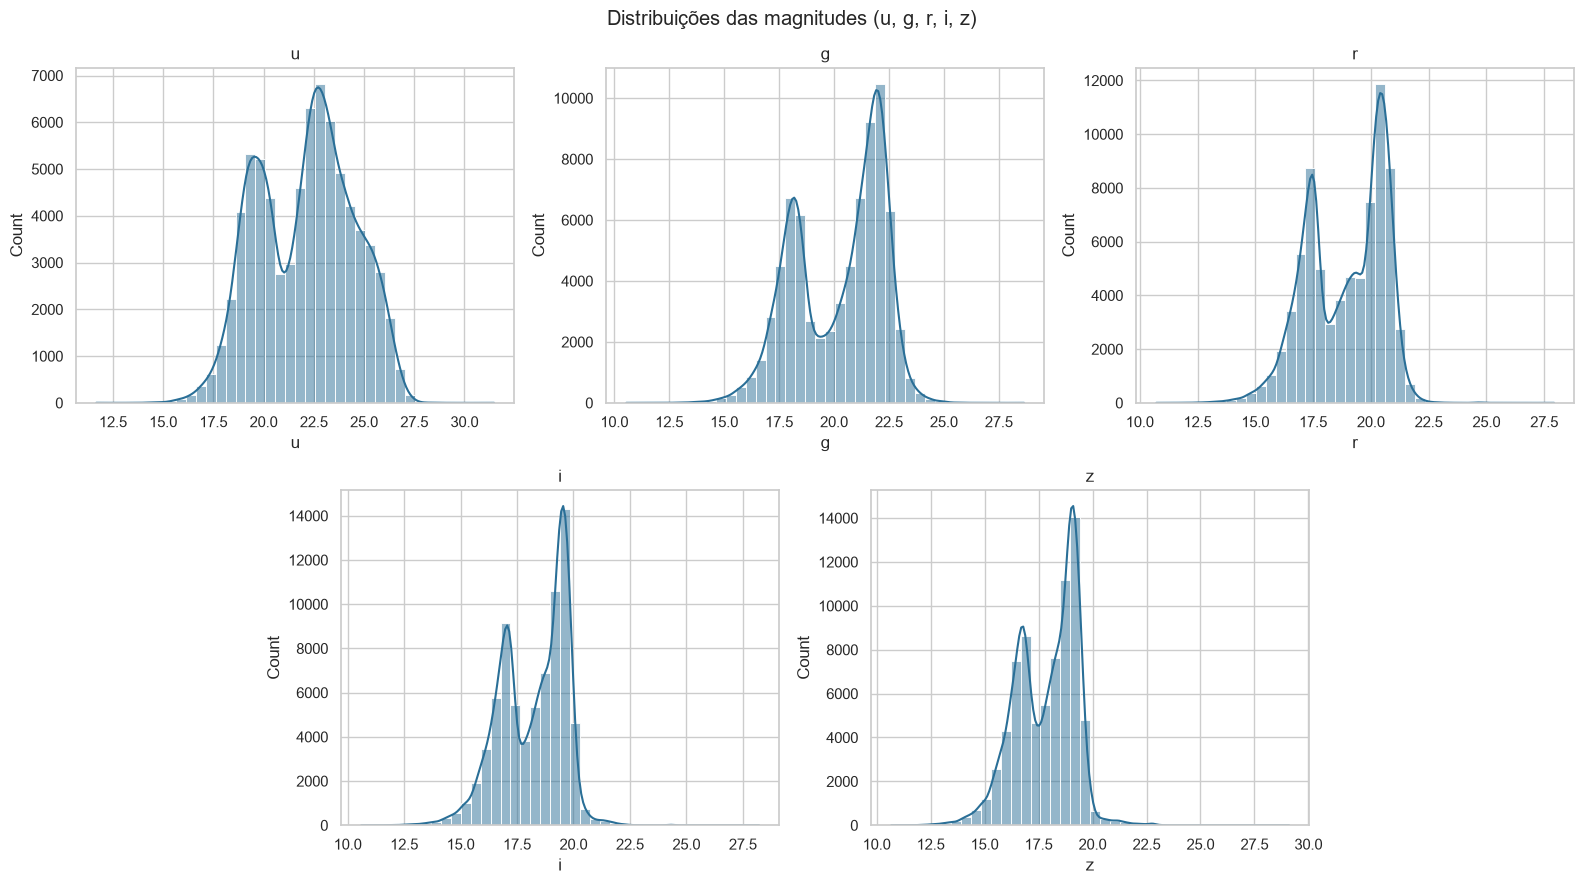

In [9]:
analysis_cols = mag_cols + err_cols + [target_col, target_err_col]
    
fig = plt.figure(figsize=(16, 9))
grid = fig.add_gridspec(2, 6)
axes = [
    fig.add_subplot(grid[0, 0:2]),
    fig.add_subplot(grid[0, 2:4]),
    fig.add_subplot(grid[0, 4:6]),
    fig.add_subplot(grid[1, 1:3]),
    fig.add_subplot(grid[1, 3:5]),
]

for ax, col in zip(axes, mag_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(col)

plt.suptitle("Distribuições das magnitudes (u, g, r, i, z)", y=0.98)
plt.tight_layout()
plt.show()


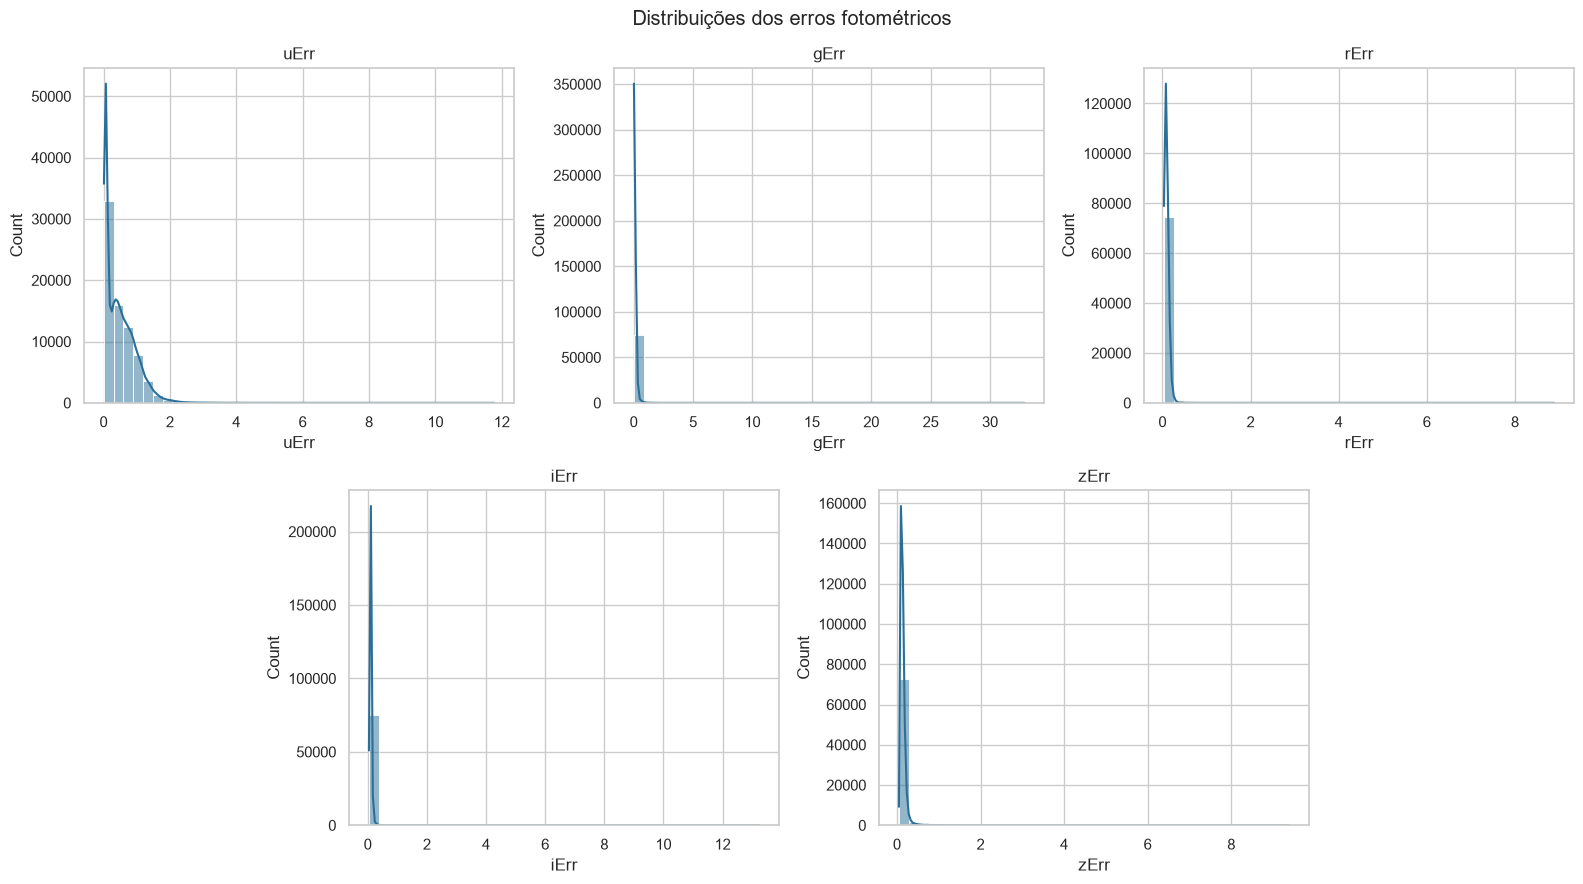

In [10]:
fig = plt.figure(figsize=(16, 9))
grid = fig.add_gridspec(2, 6)
axes = [
    fig.add_subplot(grid[0, 0:2]),
    fig.add_subplot(grid[0, 2:4]),
    fig.add_subplot(grid[0, 4:6]),
    fig.add_subplot(grid[1, 1:3]),
    fig.add_subplot(grid[1, 3:5]),
]

for ax, col in zip(axes, err_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(col)

plt.suptitle("Distribuições dos erros fotométricos", y=0.98)
plt.tight_layout()
plt.show()


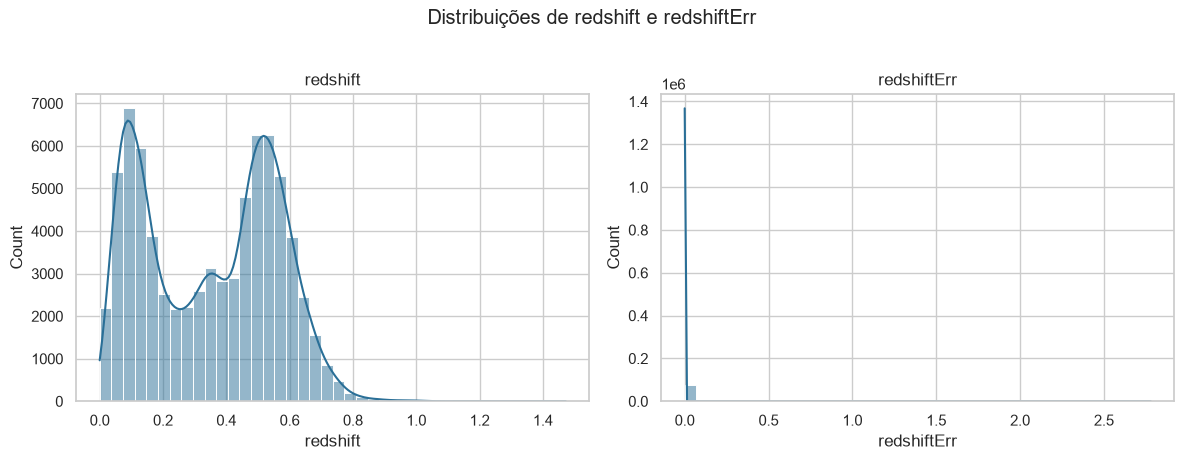

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col in zip(axes, [target_col, target_err_col]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#2a6f97")
    ax.set_title(col)

plt.suptitle("Distribuições de redshift e redshiftErr", y=1.02)
plt.tight_layout()
plt.show()


Para mostrar a assimetria de `redshiftErr` mais claramente, vamos dar um "zoom"... 

Text(0.5, 1.0, 'Distribuições de redshiftErr com zoom (quartil 0.99)')

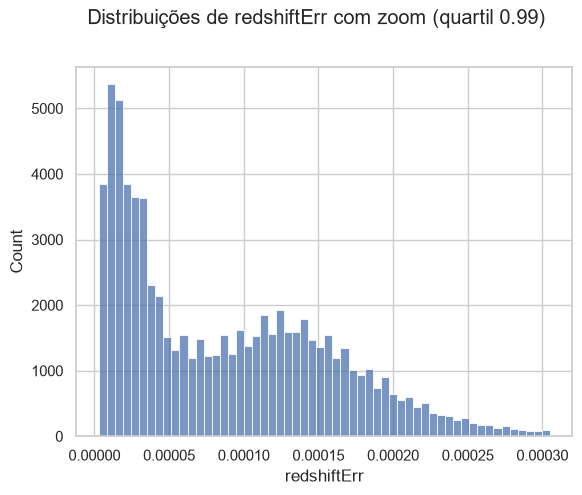

In [24]:
sns.histplot(
    df.loc[df["redshiftErr"] < df["redshiftErr"].quantile(0.99),
           "redshiftErr"]
)
plt.suptitle("Distribuições de redshiftErr com zoom (quartil 0.99)", y=1.0)


### Distribuições univariadas das variáveis

Os histogramas revelam comportamentos bastante distintos entre as magnitudes, os erros fotométricos e as variáveis associadas ao redshift.

As magnitudes das bandas **u, g, r, i e z** apresentam distribuições concentradas em faixas relativamente estreitas e com indícios de multimodalidade, sugerindo a presença de diferentes populações de objetos observados. Embora existam algumas observações extremas identificadas anteriormente, a maior parte dos dados encontra-se distribuída em regiões bem definidas, sem evidências de caudas excessivamente longas.

Os **erros fotométricos** exibem um comportamento diferente. Todas as bandas apresentam forte assimetria à direita, com grande concentração de observações próximas de valores baixos e uma cauda que se estende para valores mais elevados. Esse padrão é compatível com a expectativa física de que a maioria dos objetos possua medições relativamente precisas, enquanto uma parcela menor apresenta observações mais incertas. Esse resultado ajuda a explicar a quantidade relativamente elevada de valores classificados como extremos pela regra do IQR observada na etapa anterior.

A variável **redshift** também apresenta uma distribuição não unimodal, com regiões de maior concentração em determinados intervalos e menor densidade em outros e assimétrica a direita. Isso sugere que certos intervalos de redshift estão mais representados no catálogo do que outros, característica que pode influenciar o desempenho dos modelos ao longo das diferentes faixas de distância cosmológica.

Por fim, a variável **redshiftErr** encontra-se fortemente concentrada próxima de zero e assimétrica a direita, indicando que a grande maioria das medições espectroscópicas utilizadas como referência possui incertezas muito pequenas. Isso é desejável para a tarefa estudada, uma vez que reduz a contribuição do erro da variável alvo e permite avaliar de forma mais direta o impacto das incertezas fotométricas presentes nas variáveis de entrada.

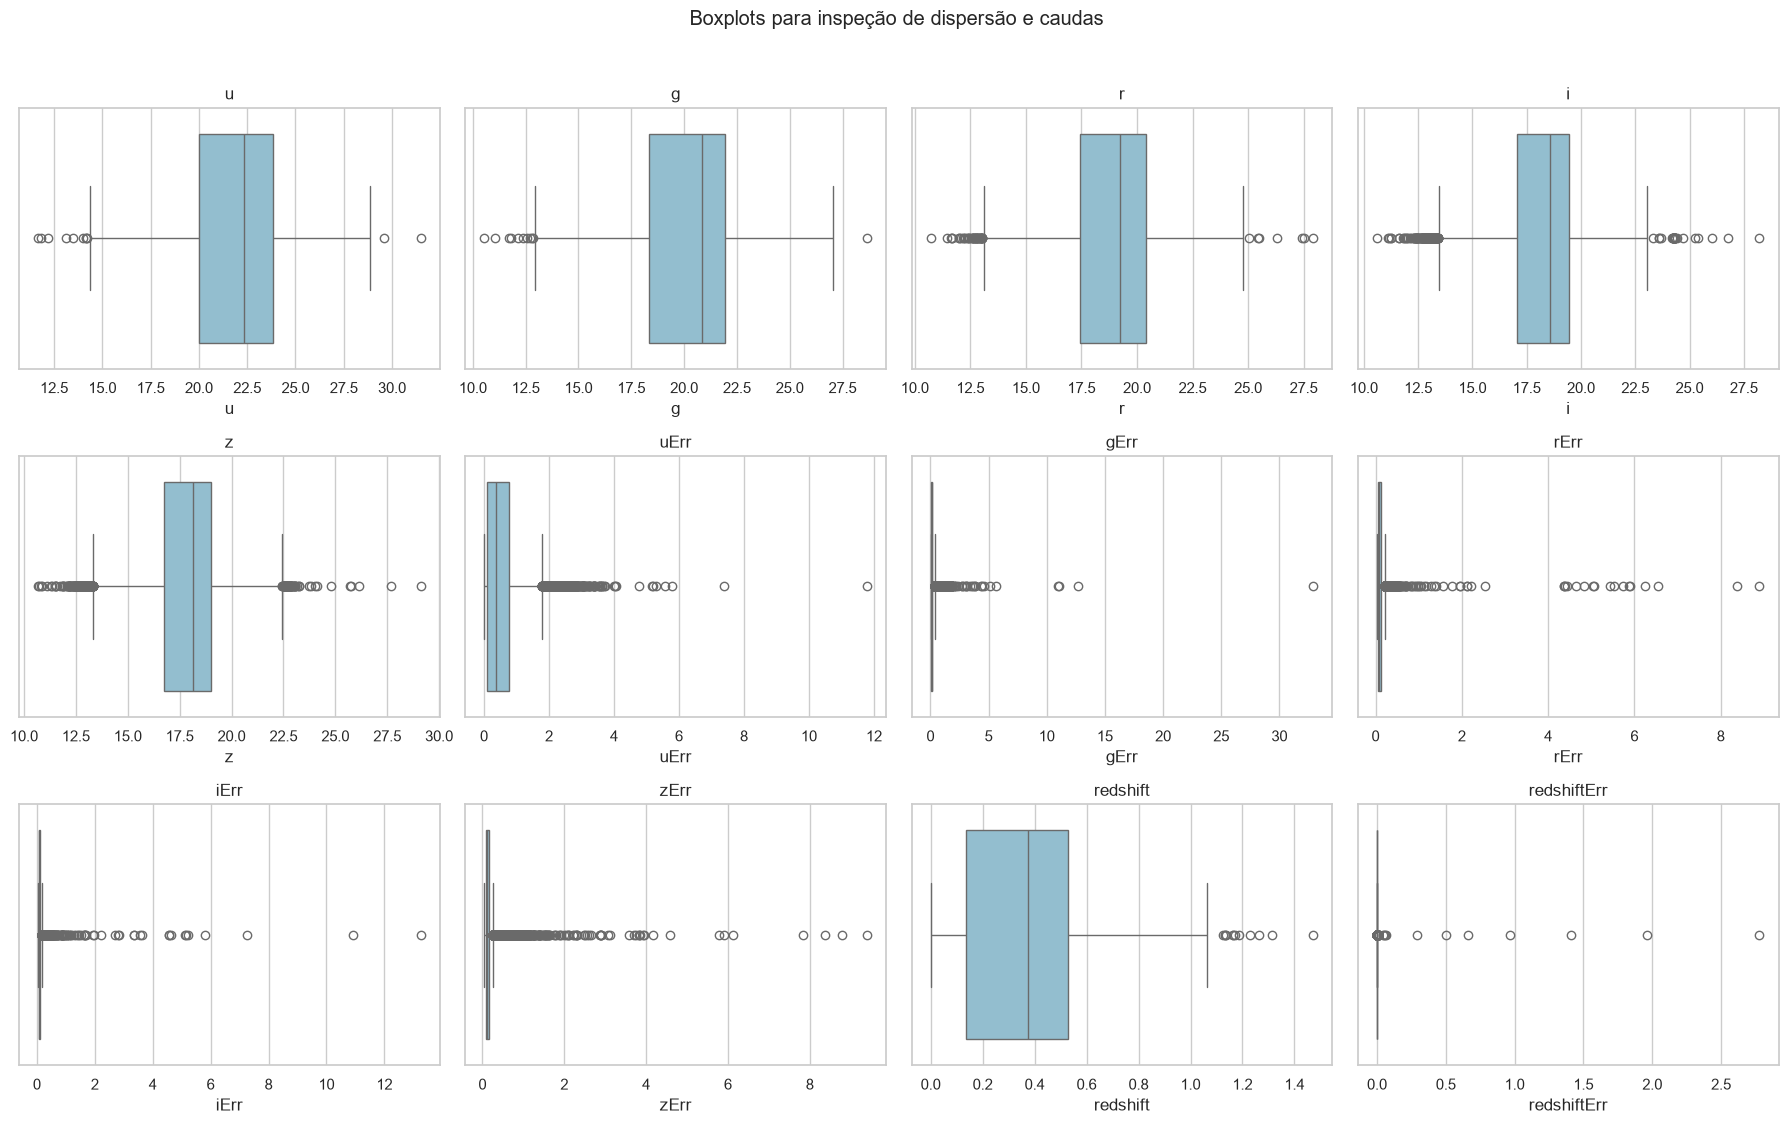

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for ax, col in zip(axes, analysis_cols):
    sns.boxplot(x=df[col], ax=ax, color="#89c2d9")
    ax.set_title(col)

for ax in axes[len(analysis_cols):]:
    ax.axis("off")

plt.suptitle("Boxplots para inspeção de dispersão e caudas", y=1.02)
plt.tight_layout()
plt.show()


### O que observar nesta etapa

Ao interpretar os gráficos acima, alguns pontos merecem atenção especial:

- **Magnitudes muito altas** indicam objetos mais fracos do ponto de vista observacional. Em geral, medições muito fracas tendem a vir acompanhadas de maior incerteza.
- **Erros fotométricos altos** sugerem menor qualidade de observação. Isso pode afetar diretamente a capacidade de um modelo aprender relações estáveis entre magnitudes e `redshift`.
- **Caudas longas** ou assimetrias acentuadas, sobretudo nas colunas de erro, podem justificar transformações, filtragens ou estratégias robustas a outliers.
- Se o **redshift estiver concentrado em uma faixa estreita**, a avaliação do modelo pode ficar enviesada para essa região, mascarando desempenho fraco em redshifts menos frequentes.
- A coluna **`redshiftErr` é informativa para diagnóstico de qualidade do alvo**, mas seu uso como feature precisa ser tratado com cautela para evitar um cenário irreal de predição.


## Fechamento parcial

Com essas três primeiras etapas, já estabelecemos uma base sólida para continuar a EDA: sabemos como o arquivo foi carregado, se existem problemas estruturais imediatos e como as variáveis principais se comportam em termos de escala, dispersão e caudas. A partir daqui, os próximos passos naturais incluem explorar relações entre variáveis, dependência com o alvo e implicações para engenharia de atributos e pré-processamento.
